In [1]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Pull the data and do initial checks.

In [2]:
bgg_mp = pd.read_csv('data/data_sources_silver/bgg_and_marketplace_20260528.csv')

In [3]:
bgg_mp.head()

,Unnamed: 0,id,game_name,publication_year,min_players,max_players,min_playtime,max_playtime,min_age,complexity,...,num_wishing,categories,mechanics,designers,publishers,families,listing_date,price_usd,condition,listing_year_month
0,0,224517,Brass: Birmingham,2018,2,4,60,120,14,3.8621,...,21932,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Gavan Brown, Matt Tolman, Martin Wallace","Roxley, Arclight Games, Board Game Rookie, Boa...","Cities: Birmingham (England), Components: Map ...",2019-12-05 11:28:16,118.80,new,2019-12
1,1,224517,Brass: Birmingham,2018,2,4,60,120,14,3.8621,...,21932,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Gavan Brown, Matt Tolman, Martin Wallace","Roxley, Arclight Games, Board Game Rookie, Boa...","Cities: Birmingham (England), Components: Map ...",2019-12-10 16:06:41,88.80,likenew,2019-12
2,2,224517,Brass: Birmingham,2018,2,4,60,120,14,3.8621,...,21932,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Gavan Brown, Matt Tolman, Martin Wallace","Roxley, Arclight Games, Board Game Rookie, Boa...","Cities: Birmingham (England), Components: Map ...",2020-01-25 13:42:18,129.60,new,2020-01
3,3,224517,Brass: Birmingham,2018,2,4,60,120,14,3.8621,...,21932,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Gavan Brown, Matt Tolman, Martin Wallace","Roxley, Arclight Games, Board Game Rookie, Boa...","Cities: Birmingham (England), Components: Map ...",2026-03-28 00:14:08,64.99,new,2026-03
4,4,224517,Brass: Birmingham,2018,2,4,60,120,14,3.8621,...,21932,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Gavan Brown, Matt Tolman, Martin Wallace","Roxley, Arclight Games, Board Game Rookie, Boa...","Cities: Birmingham (England), Components: Map ...",2022-01-26 06:29:48,70.20,new,2022-01


In [4]:
# Keep only the columns we are interested in.

bgg_mp = bgg_mp[[
    'id',
    'game_name',
    'publication_year',
    'listing_date',
    'listing_year_month',
    'condition',
    'price_usd'
]]

In [5]:
bgg_mp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260578 entries, 0 to 260577
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  260578 non-null  int64  
 1   game_name           260578 non-null  object 
 2   publication_year    260578 non-null  int64  
 3   listing_date        260578 non-null  object 
 4   listing_year_month  260578 non-null  object 
 5   condition           260578 non-null  object 
 6   price_usd           260578 non-null  float64
dtypes: float64(1), int64(2), object(4)
memory usage: 13.9+ MB


### Looking for pricing outliers

In [6]:
bgg_mp[bgg_mp['price_usd'] == bgg_mp['price_usd'].max()]

,id,game_name,publication_year,listing_date,listing_year_month,condition,price_usd
37052,286063,The 7th Citadel,2024,2026-04-01 22:25:49,2026-04,new,499.99
72615,304531,Ascension Tactics: Miniatures Deckbuilding Game,2022,2022-05-18 17:31:18,2022-05,new,499.99
181260,159011,Thornwatch,2018,2018-06-27 21:05:07,2018-06,new,499.99
235948,19440,3D Game Board,1956,2020-08-25 19:18:21,2020-08,good,499.99


Find the outliers per game.
1. generate z-score by group
2. identify prices that are outside 3 standard deviations from the mean

In [7]:
bgg_mp.columns

Index(['id', 'game_name', 'publication_year', 'listing_date',
       'listing_year_month', 'condition', 'price_usd'],
      dtype='object')

In [8]:
zscore = lambda x: (x - x.mean()) / x.std()

bgg_mp['game_price_zscore'] = bgg_mp.groupby('id')['price_usd'].transform(zscore)

In [9]:
# percentage of prices identified as outliers
len(bgg_mp[abs(bgg_mp['game_price_zscore']) > 3]) / len(bgg_mp) * 100

0.706506305213794

In [10]:
outliers = bgg_mp[abs(bgg_mp['game_price_zscore']) > 3]

bgg_mp_clean = bgg_mp[(abs(bgg_mp['game_price_zscore']) <= 3) & (bgg_mp['price_usd'] < 9999999)] # found value of 9999999.00 that was not caught by z-score
bgg_mp_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243591 entries, 0 to 260575
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  243591 non-null  int64  
 1   game_name           243591 non-null  object 
 2   publication_year    243591 non-null  int64  
 3   listing_date        243591 non-null  object 
 4   listing_year_month  243591 non-null  object 
 5   condition           243591 non-null  object 
 6   price_usd           243591 non-null  float64
 7   game_price_zscore   243591 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 16.7+ MB


## Exploring different options for transforming the price.

In [11]:
bgg_mp_clean['price_log10'] = np.log10(bgg_mp['price_usd'])
bgg_mp_clean['price_ln'] = np.log(bgg_mp['price_usd'])

In [12]:
bgg_mp_clean.head()

,id,game_name,publication_year,listing_date,listing_year_month,condition,price_usd,game_price_zscore,price_log10,price_ln
0,224517,Brass: Birmingham,2018,2019-12-05 11:28:16,2019-12,new,118.80,0.686435,2.074816,4.777441
1,224517,Brass: Birmingham,2018,2019-12-10 16:06:41,2019-12,likenew,88.80,-0.003325,1.948413,4.486387
2,224517,Brass: Birmingham,2018,2020-01-25 13:42:18,2020-01,new,129.60,0.934748,2.112605,4.864453
3,224517,Brass: Birmingham,2018,2026-03-28 00:14:08,2026-03,new,64.99,-0.550764,1.812847,4.174233
4,224517,Brass: Birmingham,2018,2022-01-26 06:29:48,2022-01,new,70.20,-0.430976,1.846337,4.251348


Text(0.5, 1.0, 'Distribution of log-transformed and normalized price_usd')

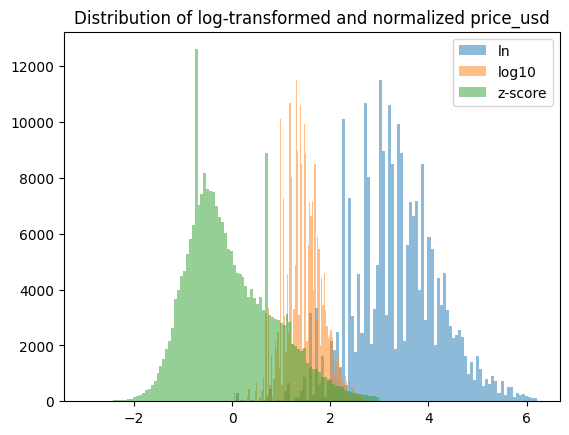

In [13]:
plt.hist(bgg_mp_clean['price_ln'], bins=100, alpha=0.5)
plt.hist(bgg_mp_clean['price_log10'], bins=100, alpha=0.5)
plt.hist(bgg_mp_clean['game_price_zscore'], bins=100, alpha=0.5)
plt.legend(['ln', 'log10', 'z-score'])
plt.title('Distribution of log-transformed and normalized price_usd')

## Maybe we should limit the pricing data due to dropoff in sales.

To investigate this, we want to calculate the total sales grouped by number of months (int) from the games first listing. We will use this to generate a plot that will show if there is an obvious drop-off in sales after a certain number of months.

In [14]:
bgg_mp_clean['listing_date'] = pd.to_datetime(bgg_mp_clean['listing_date'])
bgg_mp_clean['listing_date'].head()

0   2019-12-05 11:28:16
1   2019-12-10 16:06:41
2   2020-01-25 13:42:18
3   2026-03-28 00:14:08
4   2022-01-26 06:29:48
Name: listing_date, dtype: datetime64[ns]

In [15]:
listing_month_norm = lambda x: (
    (x.dt.year - x.min().year) * 12 + 
    (x.dt.month - x.min().month)
)

bgg_mp_clean['listing_month_int'] = bgg_mp_clean.groupby('id')['listing_date'].transform(listing_month_norm)

In [16]:
bgg_mp_clean.head()

,id,game_name,publication_year,listing_date,listing_year_month,condition,price_usd,game_price_zscore,price_log10,price_ln,listing_month_int
0,224517,Brass: Birmingham,2018,2019-12-05 11:28:16,2019-12,new,118.80,0.686435,2.074816,4.777441,0
1,224517,Brass: Birmingham,2018,2019-12-10 16:06:41,2019-12,likenew,88.80,-0.003325,1.948413,4.486387,0
2,224517,Brass: Birmingham,2018,2020-01-25 13:42:18,2020-01,new,129.60,0.934748,2.112605,4.864453,1
3,224517,Brass: Birmingham,2018,2026-03-28 00:14:08,2026-03,new,64.99,-0.550764,1.812847,4.174233,75
4,224517,Brass: Birmingham,2018,2022-01-26 06:29:48,2022-01,new,70.20,-0.430976,1.846337,4.251348,25


In [17]:
game_monthly_sales = bgg_mp_clean.groupby(['id', 'listing_month_int'])[['price_usd', 'price_log10', 'price_ln']].sum().reset_index()

In [18]:
game_monthly_sales

,id,listing_month_int,price_usd,price_log10,price_ln
0,1,0,95.25,1.978865,4.556505
1,1,9,91.80,1.962843,4.519612
2,1,21,81.00,1.908485,4.394449
3,1,26,180.00,2.255273,5.192957
4,1,35,54.00,1.732394,3.988984
...,...,...,...,...,...
198963,467539,2,17.28,1.237544,2.849550
198964,467943,0,15.00,1.176091,2.708050
198965,467943,1,39.00,2.579784,5.940171
198966,469863,0,23.00,2.079181,4.787492


In [19]:
monthly_pct = lambda x: x / x.sum()
game_monthly_sales['game_sales_pct'] = game_monthly_sales.groupby('id')['price_usd'].transform(monthly_pct)

In [20]:
game_monthly_sales.head()

,id,listing_month_int,price_usd,price_log10,price_ln,game_sales_pct
0,1,0,95.25,1.978865,4.556505,0.026019
1,1,9,91.80,1.962843,4.519612,0.025077
2,1,21,81.00,1.908485,4.394449,0.022126
3,1,26,180.00,2.255273,5.192957,0.049170
4,1,35,54.00,1.732394,3.988984,0.014751


Create a random subset of games and plot the month and sales_pct. Using a subset makes the plot more readable.

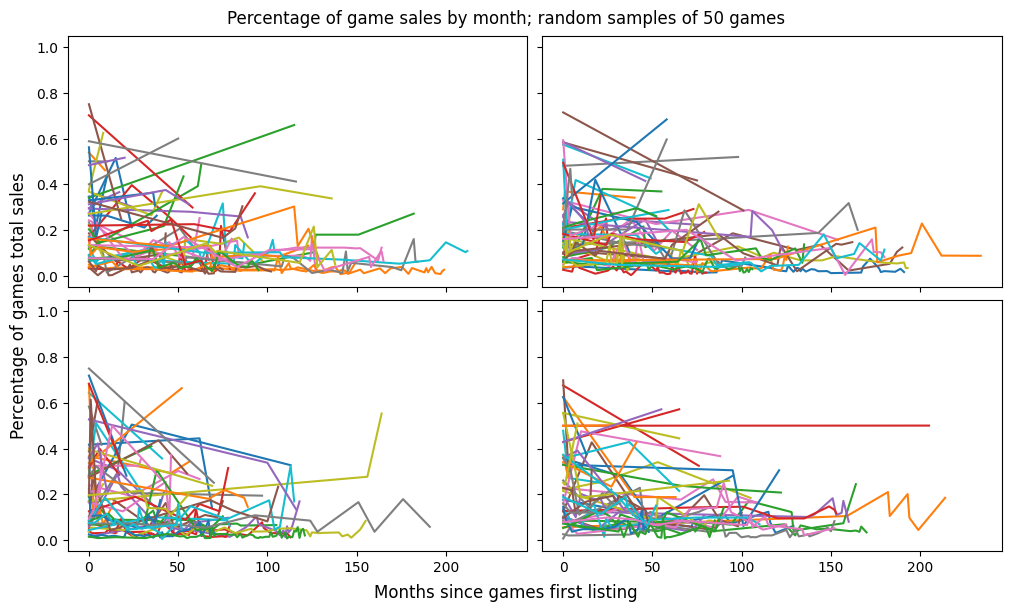

In [21]:
n=50
nrows=2
ncols=2

fig, axes = plt.subplots(nrows, ncols, figsize=(10,6), sharex=True, sharey=True, constrained_layout=True)
fig.suptitle(f'Percentage of game sales by month; random samples of {n} games')

for i in range(nrows):
    for j in range(ncols):
        subset = pd.Series(game_monthly_sales['id'].unique()).sample(n=n)
        plot_subset = game_monthly_sales[game_monthly_sales['id'].isin(subset)][['id', 'listing_month_int', 'game_sales_pct']]
        
        for game in subset:
            game_plot = plot_subset[plot_subset['id'] == game]
            axes[i,j].plot(game_plot['listing_month_int'], game_plot['game_sales_pct'])

fig.supxlabel('Months since games first listing')
fig.supylabel('Percentage of games total sales')

plt.show()

There does not seem to be a consistent or obvious dropoff trend. We will need another way to address the differing lengths of time each game has been actively traded.

## Calculate sales score per game as: 
$\text{Sales Score} = \text{Avg Monthly Sales} * \text{Months Active}^{\alpha}$

Plot with Months Active on x-axis, Monthly Avg sales on y-axis, and hue by calculated sales score.

First, calculate how many months a game has been active on the marketplace:

In [22]:
today = pd.Timestamp.today()
months_active = lambda x: (
    (today.year - x.dt.year) * 12 + 
    (today.month - x.dt.month)
)

months_active = bgg_mp_clean.groupby('id')['listing_date'].min().transform(months_active)

In [23]:
# Create a new DataFrame with game, total sales, months_active, and average sales.

sales_scores = pd.DataFrame(game_monthly_sales.groupby('id')['price_usd'].sum()).reset_index()
sales_scores = sales_scores.merge(right=months_active, on='id', how='left')
sales_scores = sales_scores.rename(columns={'price_usd': 'total_sales', 'listing_date': 'months_active'})
sales_scores['monthly_avg_sales'] = sales_scores['total_sales'] / (sales_scores['months_active'] + 1)
sales_scores.head()

,id,total_sales,months_active,monthly_avg_sales
0,1,3660.77,135,26.917426
1,2,42.00,4,8.400000
2,3,1282.31,138,9.225252
3,4,441.23,168,2.610828
4,5,6163.24,179,34.240222


In [24]:
# Calculate sales score

alphas = [0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1]
print(alphas)
alpha_cols = [f'sales_score_{alpha}' for alpha in alphas]
for alpha, col in zip(alphas, alpha_cols):
    sales_scores[col] = np.log(sales_scores['monthly_avg_sales']) * sales_scores['months_active'] ** alpha

sales_scores[alpha_cols] = (sales_scores[alpha_cols] - sales_scores[alpha_cols].min()) / (sales_scores[alpha_cols].max() - sales_scores[alpha_cols].min()) * 100
sales_scores.head()

[0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1]


,id,total_sales,months_active,monthly_avg_sales,sales_score_0,sales_score_0.125,sales_score_0.25,sales_score_0.375,sales_score_0.5,sales_score_0.625,sales_score_0.75,sales_score_0.875,sales_score_1
0,1,3660.77,135,26.917426,67.795666,74.508315,76.452148,78.354687,80.207919,82.004298,83.158022,81.232916,79.430023
1,2,42.00,4,8.400000,57.020636,55.672848,53.122583,52.361565,52.746232,53.858304,55.042043,54.474372,54.121528
2,3,1282.31,138,9.225252,57.887722,64.073843,66.203818,68.312139,70.389653,72.427466,73.902665,72.625586,71.425777
3,4,441.23,168,2.610828,46.208392,51.903968,54.387098,56.874454,59.354598,61.816075,63.803477,63.387114,62.985722
4,5,6163.24,179,34.240222,70.022090,78.109426,81.281374,84.413194,87.488940,90.493134,92.765310,91.534069,90.339919


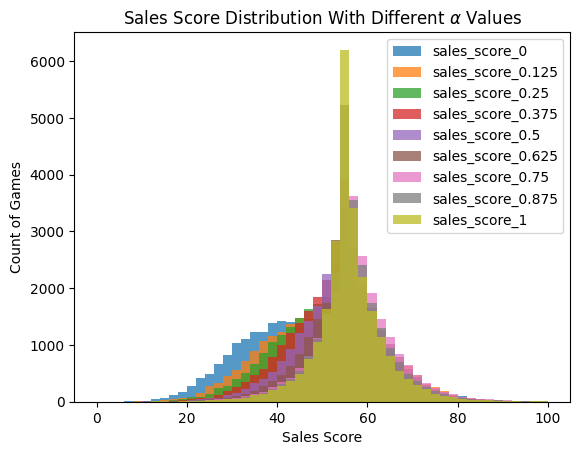

In [25]:
for col in alpha_cols:
    plt.hist(sales_scores[col], bins=50, alpha=0.75)
    # plt.hist(sales_scores['sales_score_0.5'], bins=50, alpha=0.5)
    # plt.hist(sales_scores['sales_score_0.625'], bins=50, alpha=0.5)

plt.legend(alpha_cols)
plt.title(r'Sales Score Distribution With Different $\alpha$ Values')
plt.xlabel('Sales Score')
plt.ylabel('Count of Games')
plt.show()

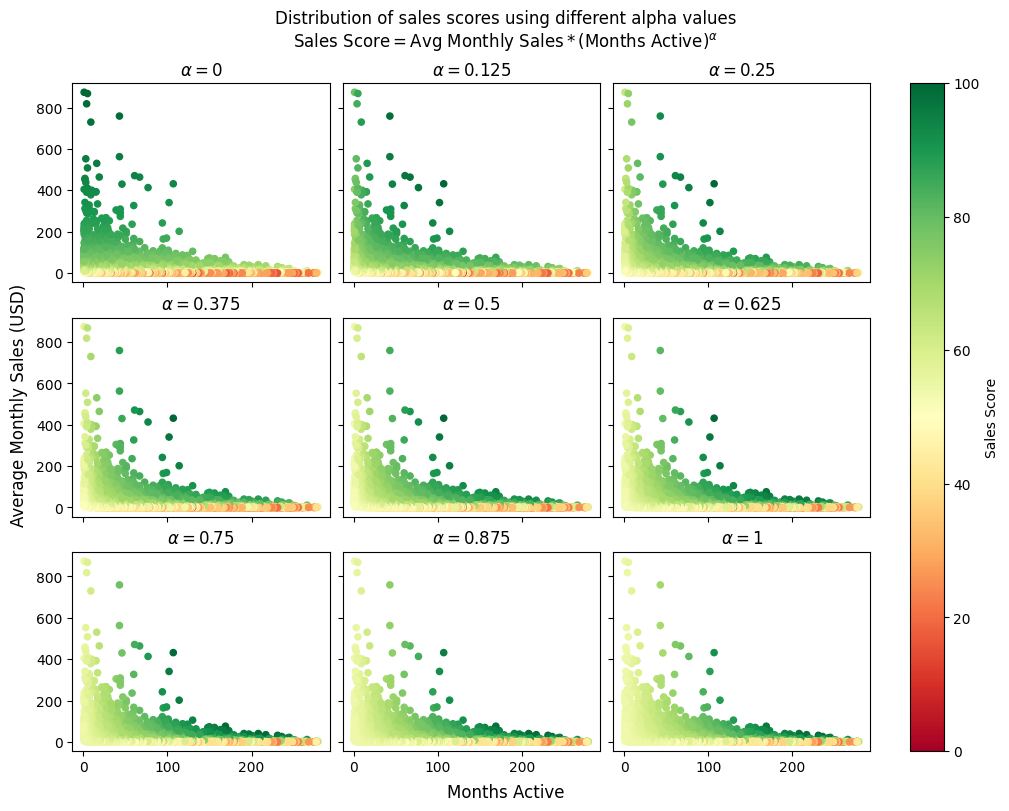

In [26]:
nrows=math.ceil(np.sqrt(len(alphas)))
ncols=math.floor(np.sqrt(len(alphas)))

fig, axes = plt.subplots(nrows, ncols, figsize=(10,8), sharex=True, sharey=True, constrained_layout=True)
axes = axes.flatten()
fig.suptitle(
    f'Distribution of sales scores using different alpha values'
    '\n'
    rf'$\text{{Sales Score}}=\text{{Avg Monthly Sales}}*(\text{{Months Active}})^{{\alpha}}$'
)

for idx, ax in enumerate(axes):
    if idx == len(alphas):
        break
    sc = ax.scatter(
        sales_scores['months_active'],
        sales_scores['monthly_avg_sales'],
        c=sales_scores[alpha_cols[idx]],
        alpha=1,
        cmap='RdYlGn',
        vmin=0,
        vmax=100,
        s=20
    )
    ax.set_title(rf'$\alpha={alphas[idx]}$')

fig.colorbar(sc, ax=axes, label='Sales Score')

fig.supxlabel('Months Active')
fig.supylabel('Average Monthly Sales (USD)')
plt.show()
fig.savefig('Figures/sales_score.png')

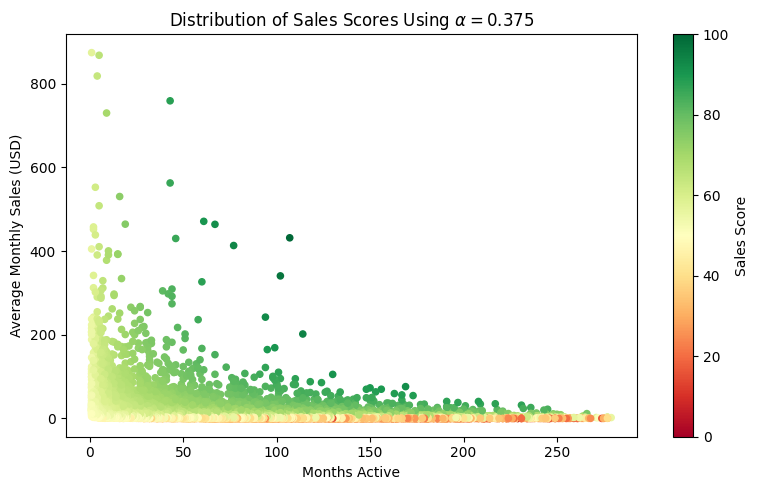

In [27]:
plt.figure(figsize=(8, 5))

sc = plt.scatter(
    sales_scores[sales_scores['monthly_avg_sales'] > 0]['months_active'],
    sales_scores[sales_scores['monthly_avg_sales'] > 0]['monthly_avg_sales'],
    c=sales_scores[sales_scores['monthly_avg_sales'] > 0]['sales_score_0.375'],
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    s=20
)


plt.colorbar(sc, label='Sales Score')

plt.title(rf'Distribution of Sales Scores Using $\alpha=0.375$')
plt.xlabel('Months Active')
plt.ylabel('Average Monthly Sales (USD)')
plt.tight_layout()
plt.savefig('Figures/sales_scores_0.375.png')
plt.show()

In [28]:
sales_scores.to_csv('data/data_sources_gold/sales_scores.csv')

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b3536b60-e481-4f67-b46c-1c4de87b554b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>